## Preprocessing code

In this notebook ill hold all code to do with preprocessing done to the image data to generate my dataset. This will involve:
* Extracting Pose data from video files
* Dataset Augmentations
* Sanity testing extraction pipeline


Links:
* PyTorch LSTM : docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

In [1]:
import os
import ast 
import json
import copy
import torch
import shutil
import random
import sklearn.metrics

import cv2 as cv
import numpy as np
import pandas as pd
import torch.nn as nn
# import mediapipe as mp
import matplotlib.pyplot as plt

from tqdm import tqdm
from joblib import dump, load
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Custom classes
from classes.GraphPlotting import GraphPlotter


RANDOM_STATE = 42

# Global vars ill use throughout the file
SWING_TYPES = ['Backhand', 'Forehand', 'NoStroke', 'Serves']
KEYPOINTS = ['NOSE','LEFT_EYE_INNER','LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR','RIGHT_EAR','MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST','RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE','RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'] 

Loading my GPU

In [2]:
# Test I can see gpu
gpu_visible = torch.cuda.is_available()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Is my GPU visible to train on :', gpu_visible)
print('Using device:', device)
print()

# Gpu stats and optimisations 
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
    # Making deterministic
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# No random variability
random.seed(RANDOM_STATE); 
np.random.seed(RANDOM_STATE); 
torch.manual_seed(RANDOM_STATE); 

Is my GPU visible to train on : True
Using device: cuda

NVIDIA GeForce RTX 3070
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


Utility functions that I use throughout this script

In [3]:
def pretty_print_json(dict_object: object):
    ''' Makes JSON object prettier for being printed 
    '''
    json_object = json.dumps(dict_object)
    parsed_json = json.loads(json_object) 
    print(json.dumps(parsed_json, indent=4))


def save_JSON_object(json_path: str, json_object: object):
    ''' Saves a JSON Object to a path
    '''
    with open(json_path, 'w') as outfile:
        json.dump(json_object, outfile)


def load_JSON_object(json_path: str):
    ''' Loads JSON object from a file
    '''
    with open(json_path, "r") as f:
        json_data = json.load(f)
        return json_data


def create_folder(folder_name: str):
    '''Used to create folders
    '''
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)


def save_torch_model(model, save_folder: str ='models/', file_name: str = None):
    ''' Saves torch models 
    Args:
        model (nn) : Model to be saved 
        save_folder (String) : String file path to folder where all models will be saved 
        file_name (String) : Name to save model as
    '''
    create_folder(save_folder)
    torch.save(model.state_dict(), f'{save_folder}{file_name}.pth')


## Create folder of frames to train on

Here I create a folder structure:

* cnn_dataset/
    * train/
        * Bakchand/
            * BH_1/
            * ...
        * Forehand
            * FH_1/
            * ...
        * ...
    * val/
        * Bakchand/
            * BH_1/
            * ...
        * Forehand
            * FH_1/
            * ...
        * ...
    * test/
        * Bakchand/
            * BH_1/
            * ...
        * Forehand
            * FH_1/
            * ...
        * ...
    
        


In [ ]:
def build_path_dict(base_path:str, folders:str):
    ''' Create a list of all file paths to folder that contain each spefcific action
    Args:
        base_path (String) : Base path to video frames folder
        folders (String) : video_frames/ subfolders to generate folder paths from
    Returns:
        path_dict (Dict) : Dict where K == Action & V == List of folders paths to folders of frames containing that action
    ''' 
    path_dict = {'Forehand' : [], 'Backhand' : [], 'Serves' : [], 'NoStroke' : []}
    for folder in folders:
        for swing_type in os.listdir(f'{base_path}{folder}/'):
            for sample_id in os.listdir(f'{base_path}{folder}/{swing_type}/'):
                # print(f'{base_path}{folder}/{swing_type}/{sample_id}/')
                # a-b
                path_dict[swing_type].append(f'{base_path}{folder}/{swing_type}/{sample_id}/')
    
    sizes = {k : len(v) for k, v in path_dict.items()}
    pretty_print_json(sizes)
    return path_dict



def build_stratified_dataset(path_dict:dict, ratio:dict ={'train':0.7, 'val':0.15, 'test':0.15}):
    ''' Build stratified dataset using the path dict
    Args:
        path_dict (Dict) : Dict where K == Action & V == List of folders paths to folders of frames containing that action
        ratio (Dict) : Dataset split ratio
    Returns:
        dataset_split (Dict) : Dict where K == split folder & V == file paths for that split
    '''
    dataset_split = {'train' : [], 'val' : [], 'test': []}
    # Randomly add each ratio % of swing types to each split
    for swing_type, path_list in path_dict.items():
        random.shuffle(path_list)
        # Calculate how mahy files go in each folder
        num_samples = len(path_list)
        num_train = int(num_samples * ratio['train'])
        num_val = int(num_samples * ratio['val'])
        train_clips = path_list[:num_train]
        val_clips = path_list[num_train : num_train + num_val]
        test_clips = path_list[num_train + num_val:]
        # Move file paths to each split list 
        dataset_split['train'].extend([(p, swing_type) for p in train_clips])
        dataset_split['val'].extend([(p, swing_type) for p in val_clips])
        dataset_split['test'].extend([(p, swing_type) for p in test_clips])
    # sizes = {k : len(v) for k, v in dataset_split.items()}
    return dataset_split
    



def create_cnn_dataset(dataset_split:str, output_base:str):
    ''' Copy files into new dataset folder
    Args:
        dataset_split (Dict) : Dict where K == split folder & V == file paths for that split
        output_base (String) : Folder to copy all folders of files to 
    Returns:
        create dataset at output base with folder structure in MD cell above
    '''
    for split, path_class_tuples in dataset_split.items():
        create_folder(f'{output_base}{split}/')
        for i in SWING_TYPES:
            create_folder(f'{output_base}{split}/{i}/')
        
        for (path, swing_type) in tqdm(path_class_tuples, desc = split):
            uid = path.split("/")[-2]
            create_folder(f'{output_base}{split}/{swing_type}/{uid}/')
            for file in os.listdir(path):
                # print('src:', f'{path}{file}')
                # print('dest:', f'{output_base}{split}/{swing_type}/{uid}/{file}')
                # a-b
                shutil.copy(f'{path}{file}', f'{output_base}{split}/{swing_type}/{uid}/{file}')





# Create base folder to save train / val and test in
output_base = 'data/video_frames/cnn_dataset/'
create_folder(output_base)
folders = ['raw', 'mirrored_video_frames']

# Get total distrribution stats
path_dict = build_path_dict('data/video_frames/', folders)

dataset_split = build_stratified_dataset(path_dict)

# Main function for creating image dataset
create_cnn_dataset(dataset_split, output_base)

{
    "Forehand": 40,
    "Backhand": 40,
    "Serves": 40,
    "NoStroke": 80
}


test: 100%|██████████| 30/30 [00:16<00:00,  1.83it/s]


## Training pipeline

In this section is where ill define:
* A simple data loader pipeline for the dataset to take the splitt dataset from above cell
* My CNN model Acrhitecture
* My training pipeline

CNN Architecture

In [6]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset

class TennisClipDataset(Dataset):
    def __init__(self, root_dir, class_names, num_frames=16, transform=None):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.transform = transform
        self.class_names = class_names
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        self.samples = []
        for class_name in class_names:
            class_path = f'{root_dir}/{class_name}'
            for clip_name in os.listdir(class_path):
                clip_path = f'{class_path}/{clip_name}'
                label = self.class_to_idx[class_name]
                self.samples.append((clip_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_path, label = self.samples[idx]
        # Get all frame file paths 
        frame_paths = sorted(glob.glob(os.path.join(clip_path, "*.jpg")))
        num_frames = len(frame_paths)
        # Extract frames we want as sample
        frame_indices = torch.linspace(0, num_frames - 1, steps=self.num_frames).long()

        # Load frames into memory
        frame_images = []
        for frame_index in frame_indices:
            frame = Image.open(frame_paths[int(frame_index)]).convert("RGB")
            frame = self.transform(frame)
            frame_images.append(frame)
        clip_tensor = torch.stack(frame_images, dim=0)

        return clip_tensor, label



In [7]:
from torch.utils.data import DataLoader
from torchvision import transforms

# Transform
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

frames_per_clip = 16

train_dataset = TennisClipDataset(
    root_dir='data/video_frames/cnn_dataset/train',
    class_names=SWING_TYPES,
    num_frames=frames_per_clip,
    transform=transform
)

val_dataset = TennisClipDataset(
    root_dir='data/video_frames/cnn_dataset/val',
    class_names=SWING_TYPES,
    num_frames=frames_per_clip,
    transform=transform
)

test_dataset = TennisClipDataset(
    root_dir='data/video_frames/cnn_dataset/test',
    class_names=SWING_TYPES,
    num_frames=frames_per_clip,
    transform=transform
)

# NOTE - num_workers > 0 making it stall out for some reason come back to this
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes:int =4, input_height:int =128, input_width:int =128):
        super().__init__()

        # Feature extractor for individual frames
        self.frame_feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        # Compute the flattened feature size using a frame
        dummy = torch.zeros(1, 3, input_height, input_width)
        with torch.no_grad():
            dummy_features = self.frame_feature_extractor(dummy)
        flattened_feature_size = dummy_features.numel()

        # Fully connected classification head
        self.classifier = nn.Sequential(
            nn.Linear(in_features=flattened_feature_size, out_features=128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=128, out_features=num_classes),
        )

    def forward(self, video_tensor:torch.Tensor):
        ''' Foward pass 
        Args:
            video_tensor (ndarray) : vidoe sequence as tensors
        Returns: 
            logits () : Probabilities of each class
        '''
        # Merge batch and time dimensions to process all frames as a batch
        batch_size, num_frames, channels, height, width = video_tensor.shape
        video_tensor = video_tensor.view(batch_size * num_frames, channels, height, width)
        # Extract spatial feats for each frame & flatten dims
        frame_features = self.frame_feature_extractor(video_tensor)
        frame_features = frame_features.view(batch_size * num_frames, -1)
        # Reshape back to (batch, time, features) and get AVG
        frame_features = frame_features.view(batch_size, num_frames, -1)
        video_features = frame_features.mean(dim=1)
        logits = self.classifier(video_features)
        return logits


## Training loop

In [ ]:
def train_model(model, epochs: int, device, train_loader, val_loader, train_size, val_size, batch_size:int =64,lr: float =0.003, weight_decay: float =0.0001, patience: int =5, min_delta: float =1e-3, save_best: bool =False, best_save_dir:str = None):
    ''' Training loop
    Args:
        model (Object) : Model architecture being trained
        epochs (Int) : Num epochs to train for 
        device_type (String) : Device being trained on either 'cuda' or 'cpu'
        batch_size (Int) : Num samples per batch
        lr (Float) : Learning rate 
        weight_decay (Float) : Float udner for regularisation
        patience (Int) : Num epochs we weait for improvment before stopping
        min_delta=1e-4 (Float) : Minimum improvement needed for patience to be reset
    Returns:
        model (Model) : Trained model
        training_history (Dict) : Dict where K == metric && V == List containing metrics value over training epochs
    '''
    # label_smoothing to try reduce variance in val loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05) 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    
    # Training stats collection
    training_history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "train_f1": [],   "val_f1": []
    }
    # Earlly stopping variables
    best_val_loss = float("inf")
    epochs_without_improve = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f'Epoch: {epoch + 1}/{epochs}')
        model.train()

        train_preds = []
        full_y_train = []
        running_val_loss = 0.0
        running_train_loss = 0.0
        running_val_corrects = 0
        running_train_corrects = 0
        
        for i, (X_train, y_train) in tqdm(enumerate(train_loader), desc=f'Epoch: {epoch}'):
            X_train = X_train.to(device, non_blocking=True)
            y_train = y_train.to(device, non_blocking=True)
            
            # Calculate preds & loss
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Compute statistics
            running_train_loss += loss.item() * X_train.size(0)
            running_train_corrects += torch.sum(torch.argmax(outputs, dim=1) == y_train)
            
            t_preds = torch.argmax(outputs, dim=1)
            train_preds.extend(t_preds.detach().cpu().tolist())
            full_y_train.extend(y_train.detach().cpu().tolist())
        
        # Compute statistics for the entire epoch
        epoch_train_loss = running_train_loss / train_size
        epoch_train_acc = running_train_corrects.item() / train_size * 100
        epoch_train_f1_macro = sklearn.metrics.f1_score(full_y_train, train_preds, average = 'macro')
        
        # Save history stats
        training_history["train_loss"].append(epoch_train_loss)
        training_history["train_acc"].append(epoch_train_acc)
        training_history["train_f1"].append(epoch_train_f1_macro)


        # Evaluation on validation set
        val_preds = []
        full_y_val = []
        model.eval()
        with torch.no_grad():
            for X_val, y_val in val_loader:
                # Move to gpu 
                X_val = X_val.to(device, non_blocking=True)
                y_val = y_val.to(device, non_blocking=True)
                
                # Calculate val loss
                val_outputs = model(X_val)
                val_loss = criterion(val_outputs, y_val)
                v_preds = torch.argmax(val_outputs, dim=1)
                val_preds.extend(v_preds.detach().cpu().tolist())
                full_y_val.extend(y_val.detach().cpu().tolist())

                # Compute statistics
                running_val_loss += val_loss.item() * X_val.size(0)
                running_val_corrects += torch.sum(torch.argmax(val_outputs, dim=1) == y_val)

        # Compute statistics for the entire epoch
        epoch_val_loss = running_val_loss / val_size
        epoch_val_acc = running_val_corrects.item() / val_size * 100
        epoch_val_f1_macro = sklearn.metrics.f1_score(full_y_val, val_preds, average='macro')
        # Reduce lr
        scheduler.step(epoch_val_loss)

        # Store history
        training_history["val_loss"].append(epoch_val_loss)
        training_history["val_acc"].append(epoch_val_acc)
        training_history["val_f1"].append(epoch_val_f1_macro)
    
        print(f'Epoch {epoch+1}/{epochs} \n   Training Loss: {epoch_train_loss:.4f}, Training Accuracy: {epoch_train_acc:.2f}%, Training F1 Macro: {epoch_train_f1_macro:.2f}% \
            \n   Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.2f}%, Validation F1 Macro: {epoch_val_f1_macro:.2f}%' )
        
        # NOTE - Early sstopping
        if epoch_val_loss < best_val_loss - min_delta:
            prev_best = best_val_loss
            best_val_loss = epoch_val_loss
            epochs_without_improve = 0
            best_state = copy.deepcopy(model.state_dict())
            if save_best:
                torch.save({
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        "best_val_loss": best_val_loss,
                    },
                    best_save_dir,
                )
            print(f"Improved from {prev_best:.5f} --> {best_val_loss:.5f}. Resetting patience")
        else:
            epochs_without_improve += 1
            print(f"No improvement ({epochs_without_improve}/{patience}).")

            if epochs_without_improve >= patience:
                print(f"Early stopping triggered (patience={patience}).")
                break
    
    # Loading the best states weights 
    model.load_state_dict(best_state)
    return model, training_history

In [ ]:
num_classes = len(SWING_TYPES)

batch_size = 16
train_size = len(train_dataset)
val_size = len(val_dataset)
create_folder("data/models/")
create_folder("data/json_data/training_history/")

model = BaselineCNN(num_classes=num_classes).to(device)

model, history = train_model(
    model=model,
    epochs=25,
    device=device,
    train_loader=train_loader,
    val_loader=val_loader,
    train_size=train_size,
    val_size=val_size,
    lr=1e-4,
    weight_decay=1e-4,
    min_delta=1e-3,
    patience=8,
    save_best=True,
    best_save_dir="data/models/baseline_cnn_best.pt",
)

save_JSON_object("data/json_data/training_history/baseline_cnn.json", history)
save_torch_model(model, save_folder="data/models/", file_name="BaselineCNN_Final")

Epoch: 1/25


Epoch: 0: 24it [01:26,  3.60s/it]


Epoch 1/25 
   Training Loss: 1.1197, Training Accuracy: 56.91%, Training F1 Macro: 0.55%             
   Validation Loss: 1.0591, Validation Accuracy: 59.65%, Validation F1 Macro: 0.41%
Improved from inf --> 1.05907. Resetting patience
Epoch: 2/25


Epoch: 1: 24it [01:00,  2.51s/it]


Epoch 2/25 
   Training Loss: 0.7217, Training Accuracy: 74.47%, Training F1 Macro: 0.75%             
   Validation Loss: 0.6547, Validation Accuracy: 77.19%, Validation F1 Macro: 0.65%
Improved from 1.05907 --> 0.65472. Resetting patience
Epoch: 3/25


...

Epoch 21/25 
   Training Loss: 0.3844, Training Accuracy: 92.02%, Training F1 Macro: 0.92%             
   Validation Loss: 0.3357, Validation Accuracy: 89.47%, Validation F1 Macro: 0.89%
No improvement (6/8).
Epoch: 22/25


Epoch: 21: 24it [00:56,  2.35s/it]


Epoch 22/25 
   Training Loss: 0.3844, Training Accuracy: 92.55%, Training F1 Macro: 0.93%             
   Validation Loss: 0.3394, Validation Accuracy: 89.47%, Validation F1 Macro: 0.89%
No improvement (7/8).
Epoch: 23/25


Epoch: 22: 24it [00:56,  2.35s/it]


Epoch 23/25 
   Training Loss: 0.3683, Training Accuracy: 91.49%, Training F1 Macro: 0.92%             
   Validation Loss: 0.3433, Validation Accuracy: 91.23%, Validation F1 Macro: 0.90%
No improvement (8/8).
Early stopping triggered (patience=8).


## In this section ill be analysing the training process for both models

In [ ]:

def plot_train_val_comparison(training_dict, train_key, val_key, title, y_label,save_dir=None, show=False):
    ''' Generic plotting function to plot train VS validation results
    Args:
        model_name (String) : Name of model who's features are being plotted
        training_dict (Dict) : Dict with K == features name && V == their progression over epochs
        train_key (String) : Key for train measure to plot
        val_key (String) : Key for validation measure to plot
        title (String) : Title
        y_label (String) : Y-Axis label
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    plt.plot(training_dict[train_key])
    plt.plot(training_dict[val_key])
    plt.title(title)
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_dir:
        plt.savefig(f'{save_dir}{title}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def plot_feature_across_trainings(model_performance_dict: dict, feature_name: str=None, y_label: str=None, save_dir=None, show=False, plot_val=True):
    ''' Function to plot training performance of a specific feature across mutliple training of models with different model architectures
    Args:
        model_performance_dict (Object) : Dict object holding all training data for all models
        feature_name (String) : Key name of feature we want to plot for all models
        varied (String) : Training variable from setup that vary
        varied (String) : Training variable from setup that are fixed
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    model_names = []
    for model_name, train_dict in model_performance_dict.items():
        plt.plot(train_dict[feature_name], label=model_name)
        model_names.append(model_name)

    title = f"{feature_name.capitalize()} comparison for {' vs '.join(model_names)}"
    print(title)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(feature_name)
    plt.legend(title="Models")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    if save_dir:
        graph_save_path = f'{save_dir}{feature_name}.png'
        plt.savefig(f'{save_dir}{feature_name}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def create_summay_df(training_histories_path):
    ''' creates a DF of the last value in each training metric for all queried models
    Args:
        training_histories_path (String) : String file path to folder
    Returns:
        summary_df (pd.DataFrame) : Summary DF of all trainin histories
    '''
    final_metrics = []
    for file_name in os.listdir(training_histories_path):
        training_data = load_JSON_object(f'data/json_data/training_history/{file_name}')
        final_metrics.append({
            "model": file_name.replace('.json', ''),
            "final_train_acc": training_data["train_acc"][-1],
            "final_val_acc": training_data["val_acc"][-1],
            "final_val_loss": training_data["val_loss"][-1],
            "final_val_f1": training_data["val_f1"][-1],
        })
    summary_df = pd.DataFrame(final_metrics)
    summary_df["generalisation_gap"] = summary_df["final_train_acc"] - summary_df["final_val_acc"]
    return summary_df



def compare_specific_models(model_list:list, training_history_folder_path:str, plot_output_folder:str):
    ''' Compare these tow if i need to
    Args:
        model_list
        training_history_folder_path
    '''
    # Load all training history data
    training_data = {model_name : load_JSON_object(f'{training_history_folder_path}{model_name}.json') for model_name in model_list}
    # print(training_data)
    plot_feature_across_trainings(training_data, feature_name='train_loss', y_label='Loss', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_acc', y_label='Accuracy', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_f1', y_label='train_f1', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)

    # Plot training progression for all graphs
    for model_name, training_history in training_data.items():
        create_folder(f'{plot_output_folder}{model_name}/')
        # Plot accuracy
        plot_train_val_comparison(training_history, train_key='train_acc', val_key='val_acc', title=f'{model_name.replace("_", " = ")} Accuracy', y_label='Accuracy', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot loss
        plot_train_val_comparison(training_history, train_key='train_loss', val_key='val_loss', title=f'{model_name.replace("_", " = ")} Loss', y_label='Loss', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot f1 macro
        plot_train_val_comparison(training_history, train_key='train_f1', val_key='val_f1', title=f'{model_name.replace("_", " = ")} F1 Macro', y_label='F1 Macro', save_dir=f'{plot_output_folder}{model_name}/', show=True)


In this cell ill call all of the plotting functionality above

Train_loss comparison for baseline_cnn


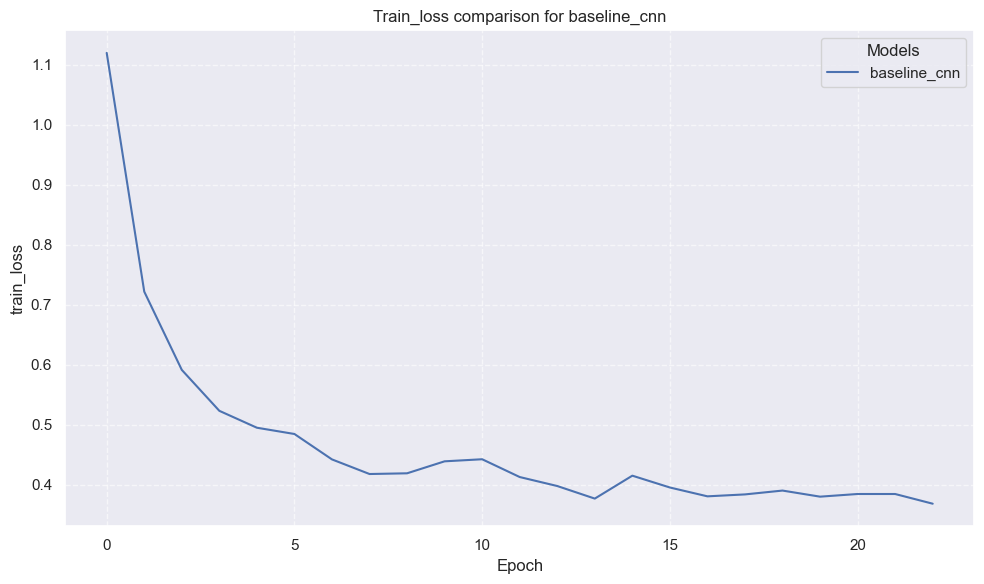

Train_acc comparison for baseline_cnn


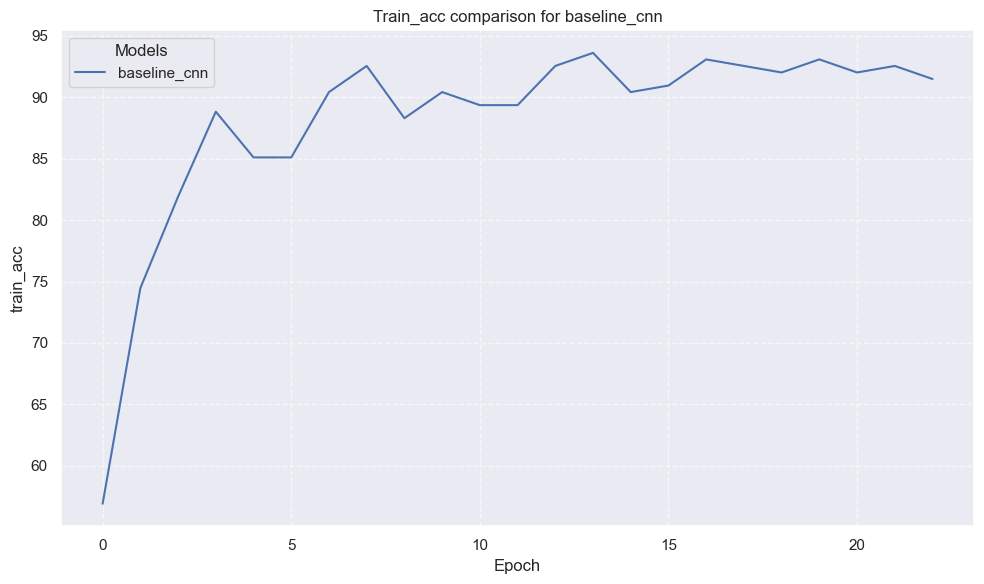

Train_f1 comparison for baseline_cnn


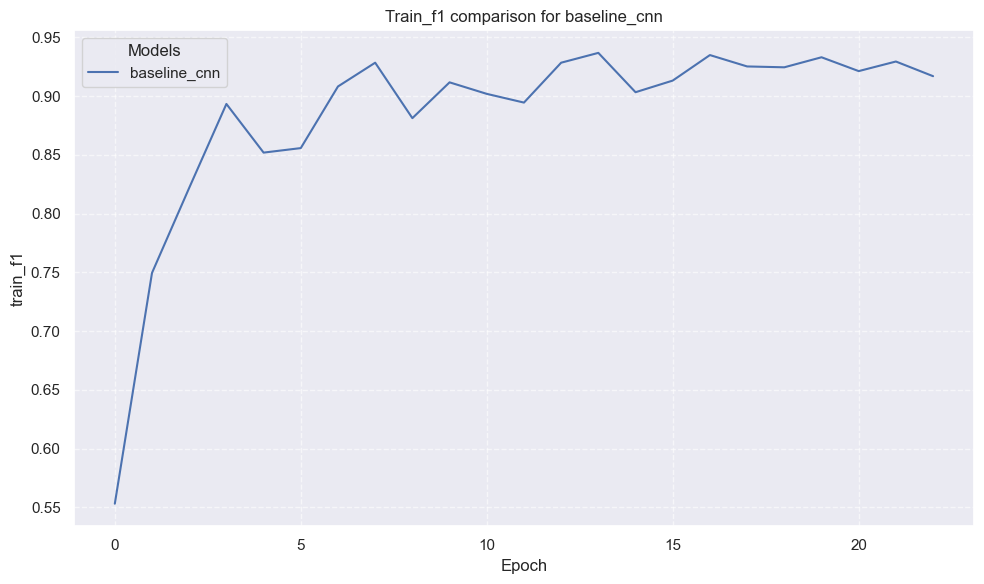

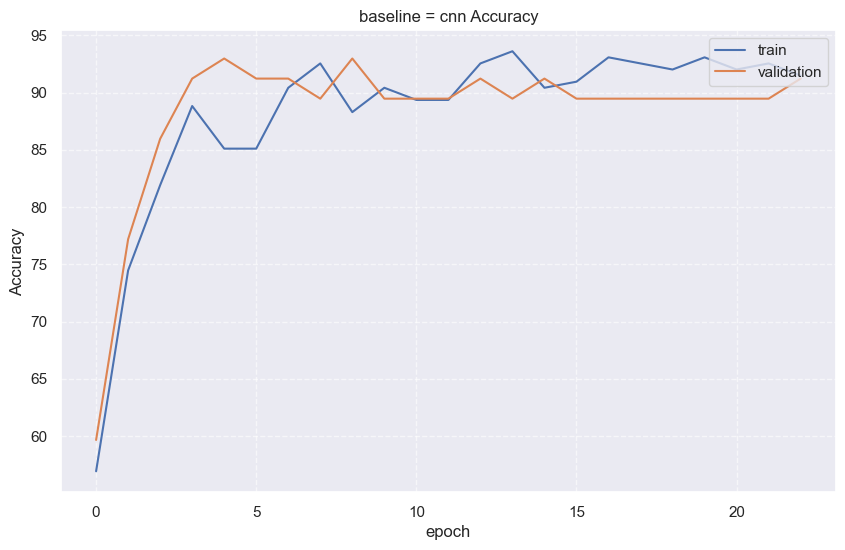

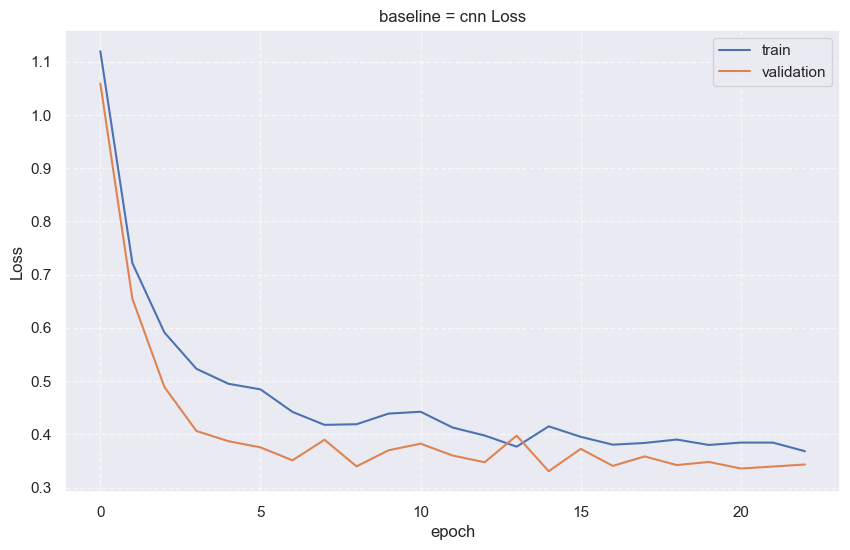

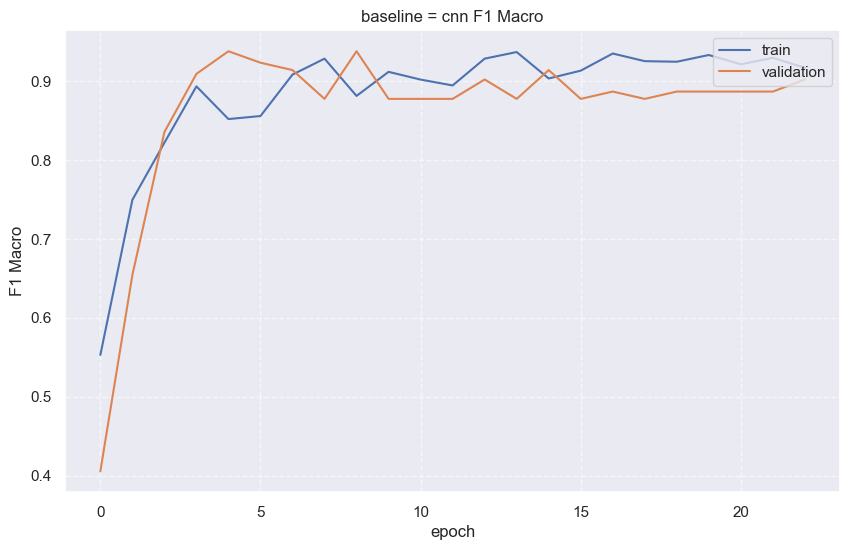

In [ ]:
# Models to compare
specific_models = ['baseline_cnn']

plot_output_folder = 'data/graphs/'
comparison_folder = 'data/graphs/model_comparison/'
training_history_folder_path = 'data/json_data/training_history/'
create_folder('data/csv/')
create_folder(comparison_folder)
create_folder(plot_output_folder)

# Plot comparisons of training metrics
compare_specific_models(specific_models, training_history_folder_path, plot_output_folder)

# Create summary fo final results for eahc model in query
summary_df = create_summay_df(training_history_folder_path)
# summary_df.to_csv('data/csv/CNN_summary_df.csv')


Test Accuracy: 0.948
Test F1 Macro: 0.954

Detailed Classification Report:
              precision    recall  f1-score   support

    Backhand      1.000     1.000     1.000        12
    Forehand      0.800     1.000     0.889        12
    NoStroke      1.000     0.864     0.927        22
      Serves      1.000     1.000     1.000        12

    accuracy                          0.948        58
   macro avg      0.950     0.966     0.954        58
weighted avg      0.959     0.948     0.949        58



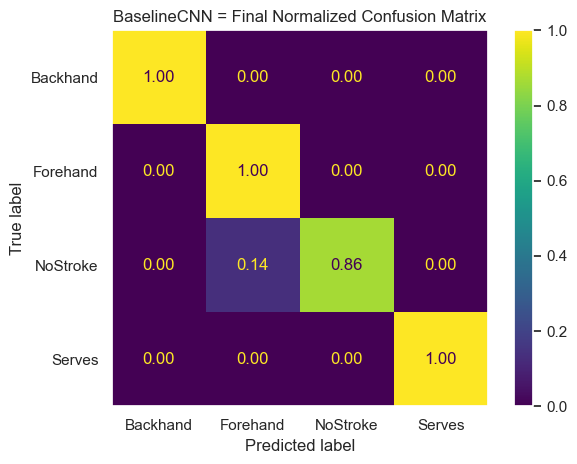

In [ ]:
# Swapping out int labels for confusion matrix
class_dict = {index : swing_name for index ,swing_name in enumerate(SWING_TYPES)}


def inference_test_set(test_loader, model):
    ''' Iterate thorugh test set and get model outputs
    Args:
       test_loader () : 
       model () :
    '''
    pred_list = []
    label_list = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            pred_list.extend(preds.cpu().numpy())
            label_list.extend(y_batch.cpu().numpy())

    return pred_list, label_list

    

def get_test_accuracy(pred_list:list, label_list:list, show=True):
    ''' Calculate the accuracy and f1 score of the model on the test set
    Args:

    '''
    test_acc = accuracy_score(label_list, pred_list)
    test_f1  = f1_score(label_list, pred_list, average='macro')
    if show:
        print(f'Test Accuracy: {test_acc:.3f}')
        print(f'Test F1 Macro: {test_f1:.3f}')
    return test_acc, test_f1




def testing_main(test_loader):
    ''' Main function for evaluating the accuracy of a trained model of a hold out test set 
    Args:
        test_loader (DataLoader) : DataLoader containing test data 
    '''
    gp = GraphPlotter('')
    create_folder('data/metrics/')

    model_name = 'BaselineCNN_Final'
    model_path = f'data/models/{model_name}.pth'

    # Make sure input_height / input_width match what you used in training
    model = BaselineCNN(num_classes=len(SWING_TYPES), input_height=128, input_width=128).to(device)

    # Load the saved weights
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    # Run inference
    y_pred, label_list = inference_test_set(test_loader, model)

    y_pred_labels = [class_dict[label_int] for label_int in y_pred]
    true_labels   = [class_dict[label_int] for label_int in label_list]
    test_acc, test_f1 = get_test_accuracy(y_pred, label_list, show=True)

    print("\nDetailed Classification Report:")
    print(classification_report(true_labels, y_pred_labels, digits=3))

    gp = GraphPlotter('')
    gp.plot_confusion_matrix(
        y_pred_labels,
        true_labels,
        title=f'{model_name.split(".")[0].replace("_", " = ")} Normalized Confusion Matrix'
    )


    # Get length of each action in test set
    # len_actions_list = [len(x) for x in X_test]
    # gp.plot_len_vs_acc(len_actions_list, y_true=true_labels, y_pred=y_pred_labels)


testing_main(test_loader)



Overall results are explored in Results_Comparison.ipynb

-- EOF --